In [4]:
import pandas as pd

df = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

df.head()
print(df.columns)
print(df.shape)

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='str')
(267, 9)


In [5]:
df.isnull().sum()

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Region.1                                    0
longitude                                   0
latitude                                    0
dtype: int64

In [9]:
print(df.columns.tolist())

['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']


In [10]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']


In [11]:
df['Date'] = pd.to_datetime(df['Date'])

print(df['Date'].dtype)

datetime64[us]


C:\Users\Admin\AppData\Local\Temp\ipykernel_11604\79498994.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [12]:
df['Year'] = df['Date'].dt.year

print(df['Year'].unique())

[2020]


In [13]:
yearly = df.groupby('Year')['Estimated Unemployment Rate (%)'].mean()

print(yearly)

Year
2020    12.236929
Name: Estimated Unemployment Rate (%), dtype: float64


In [14]:
state_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

top10 = state_avg.sort_values(ascending=False).head(10)

print(top10)

Region
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Name: Estimated Unemployment Rate (%), dtype: float64


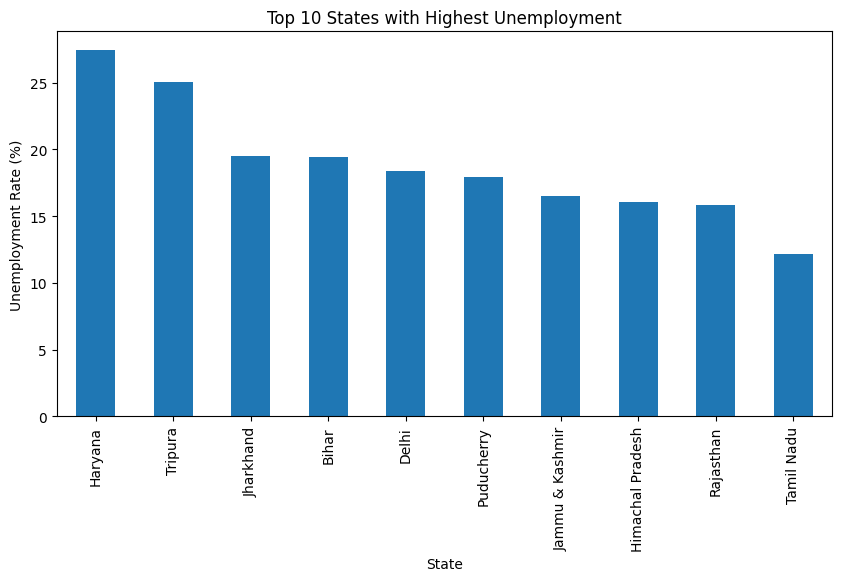

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

top10.plot(kind='bar', figsize=(10,5))

plt.title('Top 10 States with Highest Unemployment')
plt.xlabel('State')
plt.ylabel('Unemployment Rate (%)')

plt.show()

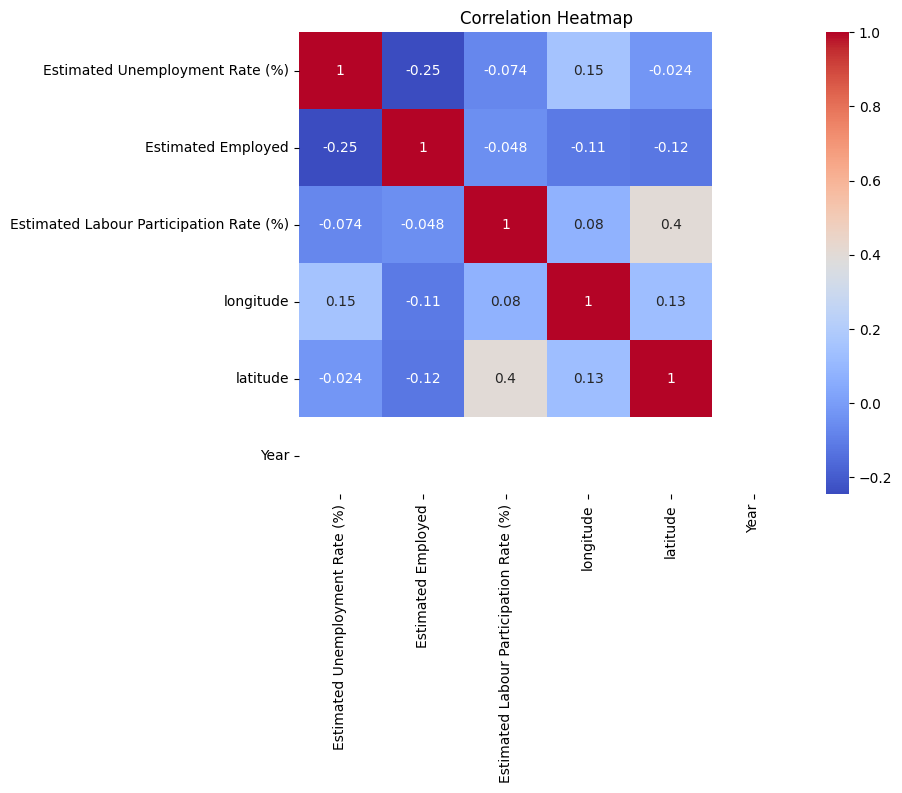

In [18]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()


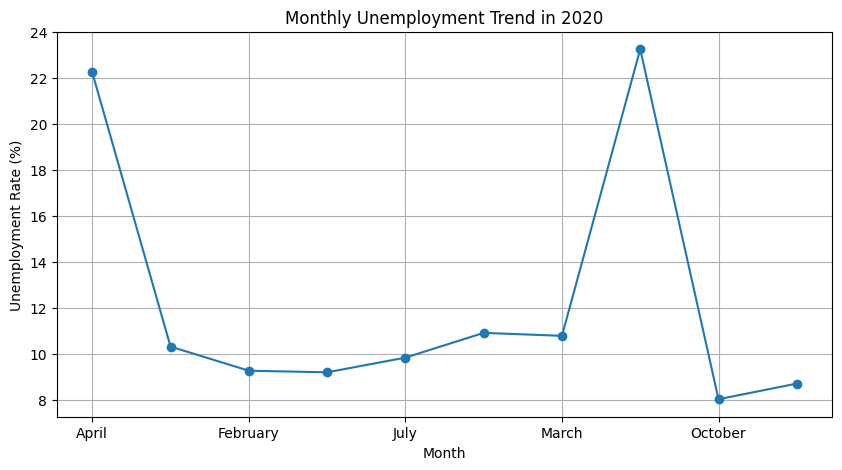

In [19]:
df['Month'] = df['Date'].dt.month_name()

monthly = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

monthly.plot(kind='line', marker='o', figsize=(10,5))

plt.title("Monthly Unemployment Trend in 2020")
plt.xlabel("Month")
plt.ylabel("Unemployment Rate (%)")

plt.grid(True)

plt.show()

# Key Insights

1. No missing values were found in the dataset.

2. Haryana recorded the highest unemployment rate among all states.

3. Tripura and Jharkhand also showed significantly high unemployment rates.

4. The monthly unemployment trend showed sharp fluctuations during 2020, indicating the impact of COVID-19 and lockdown measures.

5. Correlation analysis showed a weak negative relationship between unemployment rate and employment levels.

6. Labour participation rate had only a weak correlation with unemployment.

# Conclusion

This project analyzed unemployment trends in India using Python and data visualization techniques.

The analysis revealed significant variations in unemployment rates across different states. Haryana, Tripura, and Jharkhand recorded the highest unemployment rates during the study period.

The monthly unemployment trend highlighted the economic impact of the COVID-19 pandemic, with noticeable fluctuations in unemployment levels throughout 2020.

Overall, this project demonstrates how data analytics can help understand employment patterns and support evidence-based decision-making for economic planning and policy development.

# Policy Recommendations

- Strengthen employment generation programs in high-unemployment states.
- Expand skill development and vocational training initiatives.
- Support MSMEs and startups to create new employment opportunities.
- Improve social security measures during economic disruptions.
- Encourage digital employment and remote work opportunities.
- Promote region-specific economic development strategies.